# VinVL: Revisiting Visual Representations in Vision-Language Models

**Authors:** Pengchuan Zhang, Xiujun Li, Xiaowei Hu, Jianwei Yang, Lei Zhang, Lijuan Wang, Yejin Choi, Jianfeng Gao
**Institution:** Microsoft Corporation, University of Washington
**Date:** March 11, 2021

# https://arxiv.org/pdf/2101.00529

---

## Abstract

VinVL presents a comprehensive empirical study demonstrating that object-centric visual
representations are a critical yet underexplored component in vision-language (VL) models.
The authors develop an improved object detection (OD) model based on the ResNeXt-152 C4
architecture, pre-trained on four large-scale public datasets, and integrate it with an improved
cross-modal fusion model (OSCAR+) to establish new state-of-the-art results on seven major
VL benchmarks.

---

## Problems

- The dominant paradigm in vision-language pre-training (VLP) treats the image understanding
  module as a fixed black box, leaving visual feature quality largely unimproved since the
  Bottom-Up Top-Down (BUTD) model (Anderson et al., 2018).
- The widely-used BUTD OD model is trained solely on Visual Genome (VG), which has a
  limited object vocabulary, noisy annotations, and insufficient scale for learning rich
  visual semantics.
- Existing VLP research disproportionately focuses on improving cross-modal fusion models
  while neglecting the quality and diversity of the visual features fed into them.
- Prior OD models for VL tasks cover a narrow set of visual concepts and lack sufficient
  attribute coverage, limiting alignment with the rich semantics of natural language.

---

## Proposed Solutions

- Develop a new large-scale object-attribute detection model (X152-C4) pre-trained on four
  combined public OD datasets: COCO, OpenImages V5, Objects365 V1, and Visual Genome.
- Expand the detection vocabulary to **1,848 object categories** and **524 attribute
  categories** through vocabulary unification and class-aware sampling.
- Adopt the C4 architecture (ResNeXt-152 C4) over FPN, leveraging full ImageNet
  pre-training across all feature extraction layers and a convolutional box head with
  stronger inductive bias.
- Introduce OSCAR+, an improved VLP framework incorporating:
  - A novel **3-way Contrastive Loss** ($$\mathcal{L}_{CL3}$$) replacing the binary
    contrastive loss in OSCAR.
  - A self-training strategy using image tagging data (OpenImages) to expand the
    pre-training corpus to 8.85 million text-image-tag triples.
- Replace class-aware NMS with class-agnostic NMS to significantly accelerate inference
  without accuracy loss.

---

## Purpose

The primary purpose of this work is to rigorously demonstrate that visual feature quality
matters significantly in VL models, and to provide the community with a stronger, openly
released visual backbone that universally improves downstream VL task performance when
substituted into existing frameworks.

---

## Methodology

### Object Detection Pre-training

| Dataset         | Images | Object Classes | Sampling Strategy     |
|-----------------|--------|----------------|-----------------------|
| Visual Genome   | 97k    | 1,594          | x8 copies per epoch   |
| COCO w/ stuff   | 111k   | 171            | x8 copies per epoch   |
| Objects365 V1   | 609k   | 365            | Class-aware (CA-2k), x2 |
| OpenImages V5   | 1.67M  | 500            | Class-aware (CA-2k)   |
| **Total (merged)** | **2.49M** | **1,848** | **5.43M samples**  |

- Pre-training uses the X152-C4 backbone initialized from an ImageNet-5K checkpoint,
  trained for 1.8M iterations with batch size 16.
- Fine-tuning on VG injects attribute information (524 classes) with an attribute loss
  weight of 1.25.
- Each region feature is a tuple $$(\hat{v}, z)$$ where $$\hat{v} \in \mathbb{R}^{2048}$$
  is the region representation and $$z \in \mathbb{R}^{6}$$ encodes bounding box geometry.

### OSCAR+ Pre-training

The pre-training loss is:

$$\mathcal{L}_{\text{Pre-training}} = \mathcal{L}_{\text{MTL}} + \mathcal{L}_{CL3}$$

- **Masked Token Loss** ($$\mathcal{L}_{\text{MTL}}$$): Standard masked language modeling
  over text tokens $w$ and tag tokens $q$:

$$\mathcal{L}_{\text{MTL}} = -\mathbb{E}_{(v,h) \sim \mathcal{D}} \log p(h_i \mid h_{\backslash i}, v)$$

- **3-way Contrastive Loss** ($$\mathcal{L}_{CL3}$$): A classifier $f(\cdot)$ predicts
  whether a triplet $(w, q, v)$ is matched ($c=0$), has a polluted caption/question
  ($c=1$), or a polluted tag/answer ($c=2$):

$$\mathcal{L}_{CL3} = -\mathbb{E}_{(w,q,v;\,c) \sim \tilde{\mathcal{D}}} \log p(c \mid f(w, q, v))$$

  Training distribution: 50% matched, 25% $w$-polluted, 25% $q$-polluted triples.

### Model Variants

| Model    | BERT Init | Layers | Hidden | Attention Heads |
|----------|-----------|--------|--------|-----------------|
| OSCAR+B  | BERT-Base | 12     | 768    | 12              |
| OSCAR+L  | BERT-Large| 24     | 1024   | 16              |

Both trained for at least 1M steps; sequence lengths: 35 (language tokens), 50 (region features).

### Downstream Tasks

Models are fine-tuned on seven tasks:
- **Understanding:** VQA v2.0, GQA, NLVR2, Image-Text Retrieval (COCO 1K/5K)
- **Generation:** COCO Image Captioning, NoCaps

---

## Results

### Uniform Improvement over BUTD Baseline (BERT-Base models)

| Task                    | BUTD [2] | VinVL (Ours) | Delta   |
|-------------------------|----------|--------------|---------|
| VQA test-dev            | 73.16    | 75.95        | +2.79   |
| GQA test-dev            | 61.58    | 65.05        | +3.47   |
| Image Captioning CIDEr  | 137.6    | 140.6        | +3.0    |
| NoCaps CIDEr (overall)  | 86.58    | 92.46        | +5.88   |
| Image Retrieval R@1     | 54.0     | 58.1         | +4.1    |
| Text Retrieval R@1      | 70.0     | 74.6         | +4.6    |
| NLVR2 test-P            | 78.36    | 83.08        | +4.72   |

### State-of-the-Art Comparison (Selected)

| Task          | Previous SoTA        | VinVL-B | VinVL-L |
|---------------|----------------------|---------|---------|
| VQA test-std  | 73.82 (OSCAR-L)      | 76.12   | 76.60   |
| GQA test-std  | 63.17 (NSM)          | 64.65   | --      |
| NLVR2 test-P  | 81.47 (VILLA-L)      | 83.08   | 83.98   |
| COCO IR R@1 (5K) | 57.5 (OSCAR-L)    | 58.1    | 58.8    |

### Ablation: Contribution of Vision vs. VLP Pre-training (VQA)

| Vision Model | No VLP       | OSCAR-B | OSCAR+-B |
|--------------|--------------|---------|----------|
| R101-C4 [2]  | 68.52        | 72.38   | 72.46    |
| VinVL (X152-C4) | 71.34     | --      | 74.90    |

- Improved visual features (VinVL) account for **95%** of the total improvement from
  OSCAR-B to OSCAR+-B with VinVL (72.46 → 74.90 vs. 72.38 → 72.46).

### Key Ablation Findings

- Richer object vocabulary consistently improves VQA:
  $$\text{OI:500} \approx \text{VG-obj:317} < \text{ImageNet:1000} < \text{VG:1594}$$
- Attribute information is critical: models trained with 524 attribute classes
  significantly outperform attribute-free counterparts.
- C4 architecture outperforms FPN for VL tasks due to full ImageNet pre-training
  across all layers and a convolutional (vs. MLP) box head.
- Both region proposals and model weights independently contribute to VL performance;
  model weights have the larger impact.
- Vision pre-training on 4 merged datasets improves both grid-feature and region-feature
  based VL models.

---

## Conclusions

VinVL establishes that visual representations are a first-class citizen in vision-language
modeling, not merely a fixed preprocessing step. The proposed X152-C4 object detection model,
pre-trained on a large, diverse, and carefully merged corpus with enriched object and attribute
vocabularies, yields uniform and substantial improvements across all major VL benchmarks when
substituted into the OSCAR+ framework. The ablation study rigorously attributes approximately
95% of performance gains to improved visual features rather than VLP objective changes,
motivating future work to invest in richer visual backbones. The released model, features, and
code provide a strong and reproducible foundation for advancing the VL pre-training community.

# Mathematical and Statistical Content: VinVL

---

## 1. Core Model Formulation

The paper defines the vision-language pipeline as a two-stage function:

$$(q, v) = \text{Vision}(\text{Img}), \quad y = \text{VL}(w, q, v)$$

**What this means:**
- The image $\text{Img}$ is passed through an object detection model called $\text{Vision}$,
  which outputs two things:
  - $q$: semantic tags (detected object names as text)
  - $v$: visual feature vectors (numerical region representations)
- These, along with language input $w$ (a question or caption), are fed into a
  cross-modal fusion model $\text{VL}$ to produce output $y$ (an answer, caption, or score).
- This decomposition is the foundational abstraction of the entire paper. All experiments
  study what happens when you improve $\text{Vision}$ while keeping $\text{VL}$ fixed or
  improved jointly.

---

## 2. Region Feature Representation

Each detected image region is represented as a tuple:

$$(\hat{v},\ z), \quad \hat{v} \in \mathbb{R}^{2048}, \quad z \in \mathbb{R}^{6}$$

**What this means:**
- $\hat{v}$ is a 2048-dimensional vector extracted from the penultimate layer of the
  detection head — it encodes the visual content of the region.
- $z$ is a 6-dimensional position encoding containing the bounding box coordinates plus
  the region's height and width.
- Together they form a spatially-aware semantic descriptor for each candidate image region.
  Up to 50 such region features are extracted per image and passed to the VL model.

---

## 3. Pre-training Loss Function

The total OSCAR+ pre-training objective is a sum of two loss terms:

$$\mathcal{L}_{\text{Pre-training}} = \mathcal{L}_{\text{MTL}} + \mathcal{L}_{CL3}$$

**What this means:**
- The model is trained jointly on two complementary objectives that together teach it
  to understand both language structure and cross-modal alignment.
- Each term is described in detail below.

---

## 4. Masked Token Loss (MTL)

$$\mathcal{L}_{\text{MTL}} = -\mathbb{E}_{(v,h) \sim \mathcal{D}}\ \log p(h_i \mid h_{\backslash i},\ v)$$

**What this means:**
- $h = [w, q]$ is the concatenated sequence of language tokens (captions or questions)
  and tag tokens (object names).
- At each training step, 15% of tokens in $h$ are randomly replaced with a special
  `[MASK]` token.
- The model is trained to recover the original token $h_i$ from the remaining context
  $h_{\backslash i}$ (all other tokens) and the visual features $v$.
- This is a standard masked language modeling objective (same as BERT), extended to
  include visual grounding. It teaches the model to fill in missing words using both
  linguistic context and image content simultaneously.

---

## 5. 3-way Contrastive Loss

This is the novel contribution to the pre-training objective. A triplet of inputs is defined as:

$$x = \bigl(w_{\text{caption}},\ q,\ v\bigr) \quad \text{or} \quad \bigl(w,\ q_{\text{Q\&A}},\ v\bigr)$$

A fully-connected classifier $f(\cdot)$ acts on the `[CLS]` token representation and
assigns one of three class labels:

| Label $c$ | Meaning |
|-----------|---------|
| $c = 0$   | Matched triplet (correct) |
| $c = 1$   | Polluted $w$ (wrong caption or question) |
| $c = 2$   | Polluted $q$ (wrong tag or answer) |

The loss is:

$$\mathcal{L}_{CL3} = -\mathbb{E}_{(w,q,v;\,c)\ \sim\ \tilde{\mathcal{D}}}\ \log p\bigl(c \mid f(w, q, v)\bigr)$$

The training dataset $\tilde{\mathcal{D}}$ is constructed with fixed proportions:

$$\tilde{\mathcal{D}} = \begin{cases} 50\% & \text{matched triples } (c=0) \\ 25\% & w\text{-polluted triples } (c=1) \\ 25\% & q\text{-polluted triples } (c=2) \end{cases}$$

**What this means:**
- This is a **3-class cross-entropy classification loss** applied to the `[CLS]` token,
  which acts as a summary representation of the full triplet $(w, q, v)$.
- The model learns to detect two distinct types of mismatch: a wrong caption/question
  paired with a correct image, and a wrong tag/answer paired with a correct image.
- The binary contrastive loss in the original OSCAR only detected one type of mismatch
  ($w$-pollution), which trained the model well for VQA but poorly for text-image
  retrieval. The 3-way loss simultaneously optimizes for both tasks.
- Negative examples (polluted $w'$ and $q'$) are sampled uniformly from the entire corpus.

---

## 6. Dataset Sampling and Balancing

To construct the merged 4-dataset OD pre-training corpus, the paper applies
**class-aware sampling (CA-2k)**: for each class in OpenImages and Objects365,
images are sampled until at least 2,000 instances per class are collected.

The final merged corpus uses the following copy multipliers per epoch:

$$\text{Total samples} = 8 \times 0.11\text{M (COCO)} + 8 \times 0.1\text{M (VG)}
+ 2 \times 0.8\text{M (O365)} + 1 \times 2.2\text{M (OI)} = 5.43\text{M}$$

**What this means:**
- Datasets vary enormously in size (97k to 1.67M images). Without rebalancing, large
  datasets would dominate training and rare visual concepts would be underrepresented.
- Oversampling small but high-quality datasets (COCO, VG) and applying class-aware
  sampling to large datasets ensures that tail-class concepts receive sufficient
  gradient updates during training.

---

## 7. Vocabulary Unification

The merged object vocabulary is constructed by:

$$|\mathcal{V}_{\text{merged}}| = |\mathcal{V}_{\text{VG}}| + |\mathcal{V}_{\text{new}}|
= 1{,}594 + 254 = 1{,}848 \text{ object classes}$$

plus 524 attribute classes.

**What this means:**
- VG's vocabulary is used as the base. Classes from COCO, Objects365, and OpenImages
  are merged into it if name/alias matches exist; otherwise a new class is added.
- Only VG classes with at least 30 annotated instances are retained, filtering out
  statistically unreliable categories.
- The result is a vocabulary nearly 10 times richer in object categories than the
  original BUTD model (which used 1,600 objects and 400 attributes).

---

## 8. Ablation: Quantifying Vision vs. VLP Contribution

The paper isolates the contribution of visual features vs. VLP objectives on VQA accuracy
through a factorial ablation:

| Vision Model      | No VLP  | OSCAR-B | OSCAR+-B |
|-------------------|---------|---------|----------|
| R101-C4 (BUTD)    | 68.52   | 72.38   | 72.46    |
| X152-C4 (VinVL)   | 71.34   | --      | 74.90    |

Gain decomposition from OSCAR-B baseline (72.38) to OSCAR+-B + VinVL (74.90):

$$\Delta_{\text{total}} = 74.90 - 72.38 = 2.52 \text{ points}$$

$$\Delta_{\text{VLP}} = 72.46 - 72.38 = 0.08 \quad (\approx 5\%)$$

$$\Delta_{\text{Vision}} = 74.90 - 72.46 = 2.44 \quad (\approx 95\%)$$

Also, the gains from VinVL and VLP are shown to be approximately **additive**:

$$\Delta_{\text{VinVL}} + \Delta_{\text{VLP}} \approx (71.34 - 68.52) + (72.46 - 68.52)
= 2.82 + 3.94 \approx 6.76 \approx 74.90 - 68.52$$

**What this means:**
- The additive decomposition implies that vision pre-training and VL pre-training
  improve orthogonal components of the pipeline ($\text{Vision}$ and $\text{VL}$
  respectively), and do not interfere with each other.
- This is a key quantitative argument: 95% of the overall improvement comes purely
  from better visual features, not from changes to the VLP objective.

---

## 9. Vocabulary Size vs. Performance: Empirical Ordering

The paper establishes an empirical monotonic relationship between object vocabulary
richness and downstream VQA accuracy:

$$\text{OI:500} \approx \text{VG-obj:317} < \text{ImageNet:1000} < \text{VG:1594}
< \text{VG:1594+Attr:524} < \text{4Sets} \rightarrow \text{VG:1594+Attr:524}$$

**What this means:**
- Treating vocabulary size as an ordinal variable, each step up in vocabulary richness
  yields measurable VQA accuracy gains.
- The largest single gain comes from adding **attribute classes** (524 attributes on top
  of 1,594 objects), confirming that attributes carry significant semantic information
  for language alignment that object labels alone cannot provide.

---

## 10. Inference Time Analysis

The paper reports GPU and CPU inference times (in seconds, mean ± std) for the VQA
pipeline under different vision configurations:

| Feature Type  | Vision (GPU) | VL (GPU) | Vision (CPU) |
|---------------|--------------|----------|--------------|
| Grid-50 (X152)   | 0.355 ± 0.022 | 0.031 | 17.765 ± 1.693 |
| Region (X152)    | 0.687 ± 0.064 | 0.036 | 29.641 ± 3.097 |
| Region-eff (X152)| 0.475 ± 0.049 | 0.037 | 29.687 ± 3.011 |

**What this means:**
- Standard deviation is reported across multiple runs, providing a measure of
  inference stability.
- The efficient region extractor (class-agnostic NMS) reduces GPU inference time by
  roughly 30% (0.687 → 0.475 seconds) with no accuracy loss, but shows no benefit
  on single-thread CPU because backbone computation dominates NMS time there.
- Vision model inference dominates total time in all configurations, reinforcing that
  the visual encoder is the computational bottleneck.

---

## Summary of Mathematical Components

| Component | Type | Role in Paper |
|-----------|------|---------------|
| $\mathcal{L}_{\text{MTL}}$ | Cross-entropy / NLL | Masked language modeling with visual grounding |
| $\mathcal{L}_{CL3}$ | 3-class cross-entropy | Cross-modal alignment for retrieval and VQA |
| $(\hat{v}, z)$ region feature | Vector representation | Spatially-aware visual token input |
| Class-aware sampling | Statistical rebalancing | Handles class imbalance across merged datasets |
| Vocabulary unification | Set-theoretic merging | Constructs unified 1,848-class detection space |
| Additive gain decomposition | Factorial ablation | Quantifies independent contributions of V and VL |
| Inference time (mean ± std) | Descriptive statistics | Measures efficiency of the proposed feature extractor |

# VinVL: Problem–Gap–Solution Analysis

---

## Structured Problem–Gap–Solution Table

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution |
|---|------------------------|--------------------------|-------------------|
| 1 | **Visual features treated as a fixed black box in VLP pipelines** | The BUTD model (Anderson et al., 2018) has been used unchanged as the visual backbone in nearly all major VLP frameworks for three years, despite significant advances in object detection architectures, datasets, and training methods. Improvements in VL research have been one-sided, focusing exclusively on the cross-modal fusion stage. | A new large-scale object-attribute detection model (X152-C4) is developed from scratch with a modern architecture, trained on a significantly larger and more diverse corpus, replacing the stagnant visual backbone with a substantially stronger one. |
| 2 | **Insufficient diversity and scale of object detection training data** | The BUTD model is trained solely on Visual Genome (VG), which contains approximately 97k images with noisy annotations, a high rate of missing labels, and severe class imbalance. This limits the visual vocabulary and the quality of learned features, particularly for tail-class visual concepts critical to language alignment. | Four complementary public OD datasets — COCO, OpenImages V5, Objects365 V1, and Visual Genome — are merged into a unified corpus of 5.43 million training samples using class-aware sampling (CA-2k) and dataset-level copy multipliers to correct scale imbalance and ensure adequate tail-class representation. |
| 3 | **Narrow object and attribute vocabulary restricts visual semantic richness** | The BUTD model covers 1,600 object categories and 400 attribute categories. Many visually and linguistically important concepts (e.g., sky, water, shadow, fin, bracelet) are absent, creating a semantic gap between the visual and language modalities that degrades performance on VL understanding and generation tasks. | A unified vocabulary of 1,848 object categories and 524 attribute categories is constructed by merging class labels across all four datasets using VG vocabulary as the base, with alias matching and a minimum-instance threshold of 30 per class to filter unreliable categories. |
| 4 | **Suboptimal model architecture for visual feature extraction in VL tasks** | Feature Pyramid Network (FPN) models, despite outperforming C4 models on standard object detection benchmarks, do not produce superior region features for VL tasks. Prior work has not systematically investigated or explained this discrepancy, leading to suboptimal architecture choices in VL pipelines. | The C4 architecture (ResNeXt-152 C4) is adopted and justified through controlled experiments. Two causes of FPN's underperformance are identified: (i) FPN's MLP box head is not pre-trained on ImageNet, unlike C4's fully convolutional head; (ii) the convolutional head of C4 encodes stronger visual inductive biases than the MLP head of FPN. |
| 5 | **Attribute information underweighted during VG fine-tuning** | Prior models (including BUTD and its successors) use an attribute loss weight of 0.5 during VG fine-tuning, resulting in weak attribute detection performance. Since attributes are semantically dense and directly correspond to adjective-level language, under-detecting them reduces the expressivity of visual features for language grounding. | The attribute loss weight is increased to 1.25 during VG fine-tuning, reflecting the fact that object representations are already well-established from large-scale pre-training. This allows the VG fine-tuning stage to focus learning capacity on attribute detection, yielding significantly richer attribute-level visual representations. |
| 6 | **Binary contrastive loss in OSCAR optimizes for VQA but not text-image retrieval** | OSCAR's pre-training contrastive loss only constructs negatives by corrupting the tag sequence $q$, which closely mimics the VQA answer-selection objective. As a result, the pre-trained model transfers well to VQA but fails to learn effective cross-modal alignment for text-image retrieval, limiting its generalization across VL task types. | A novel 3-way Contrastive Loss ($\mathcal{L}_{CL3}$) is introduced that classifies triplets $(w, q, v)$ into three categories: matched, caption/question-polluted ($w'$), or tag/answer-polluted ($q'$). By simultaneously training on both types of negative, the model optimizes for both retrieval and VQA alignment objectives within a single pre-training pass. |
| 7 | **Limited pre-training corpus scale due to exclusive reliance on captioned image data** | OSCAR's pre-training corpus consists of approximately 3.98 million images with human-annotated captions and QA pairs. Large-scale image tagging datasets such as OpenImages (9M) and YFCC (92M) are left unused, representing a substantial untapped source of visual supervision. | A self-training strategy is introduced that generates pseudo-captions for image tagging datasets using OSCAR's captioning model, forming additional $(w, q, v)$ triples. This expands the OSCAR+ pre-training corpus to 5.65 million unique images and 8.85 million triples without requiring additional human annotation. |
| 8 | **Slow inference due to class-aware NMS over a large object vocabulary** | As the number of detected object categories increases (from ~1,600 to 1,848), class-aware Non-Maximum Suppression (NMS) — which applies NMS independently per class — becomes computationally prohibitive, substantially increasing feature extraction latency and limiting practical deployment. | Class-aware NMS is replaced with class-agnostic NMS, which applies a single unified NMS pass regardless of category. Additionally, dilated convolutions in the detection head are replaced with standard convolutions. Together these changes reduce GPU inference time by approximately 30% (0.687s → 0.475s) with no measurable accuracy loss on downstream VL tasks. |

---

## Summary of Gap Categories

| Gap Category | Count | Core Theme |
|---|---|---|
| Visual backbone stagnation | 1, 4 | Architecture and training methodology of the OD model |
| Training data insufficiency | 2, 3 | Scale, diversity, and vocabulary richness of OD corpora |
| Semantic representation quality | 3, 5 | Object and attribute coverage in visual features |
| VLP objective design | 6, 7 | Scope and generalization of pre-training losses and data |
| Computational efficiency | 8 | Inference speed under expanded vocabulary |

In [1]:
# ============================================================
# VinVL: Revisiting Visual Representations in Vision-Language Models
# Simplified Educational Implementation on CIFAR-10
# ============================================================
# This implementation captures VinVL's core ideas:
#   1. A rich object-attribute detection backbone (ResNet-based feature extractor)
#   2. Cross-modal fusion (image features + text/tag tokens via Transformer)
#   3. Masked Token Loss (MTL) — predicting masked class tags
#   4. 3-way Contrastive Loss (CL3) — matching image to correct tag vs. polluted tags
#   5. Classification head for downstream VQA-style answer prediction
#
# On CIFAR-10: images are paired with their class-name tags (e.g., "dog", "car").
# The model learns to align visual features with correct semantic tags.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── reproducibility ──────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ============================================================
# SECTION 1 — DATASET PREPARATION
# CIFAR-10 via HuggingFace datasets library
# 2000 train / 400 test samples (educational subset)
# ============================================================

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from PIL import Image

# CIFAR-10 class names — these serve as our "semantic tags" (q in the paper)
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
NUM_CLASSES = len(CIFAR10_CLASSES)

# ── Download from HuggingFace ─────────────────────────────────
# uoft-cs/cifar10 is the canonical CIFAR-10 on HuggingFace Hub
# splits: 'train' (50,000 samples) and 'test' (10,000 samples)
print("Downloading CIFAR-10 from HuggingFace...")
hf_dataset = load_dataset("uoft-cs/cifar10")
print(f"HuggingFace dataset loaded: {hf_dataset}")

# ── Image transforms ──────────────────────────────────────────
# Resize to 64x64, normalize to ImageNet statistics
# (VinVL uses ImageNet-pretrained backbones, so we match their normalization)
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),      # light augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],         # ImageNet mean
        std=[0.229, 0.224, 0.225]           # ImageNet std
    )
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ── Custom PyTorch Dataset wrapper for HuggingFace CIFAR-10 ───
# HuggingFace returns dicts with keys: 'img' (PIL Image) and 'label' (int)
# We wrap it in a standard PyTorch Dataset so it works with DataLoader
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a PyTorch Dataset.

    HuggingFace sample format:
        { 'img': <PIL.Image>, 'label': <int 0-9> }

    This class applies the appropriate torchvision transform
    and returns (image_tensor, label) tuples compatible with
    the rest of the VinVL training pipeline.
    """
    def __init__(self, hf_split, transform=None):
        """
        Args:
            hf_split  : a HuggingFace dataset split
                        (e.g. hf_dataset['train'] or hf_dataset['test'])
            transform : torchvision transform pipeline to apply to each image
        """
        self.data      = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        # HuggingFace stores images as PIL Images under the key 'img'
        image = sample['img']

        # Ensure image is RGB — CIFAR-10 is always RGB but good practice
        if image.mode != 'RGB':
            image = image.convert('RGB')

        # Apply transforms (resize, normalize, augment, etc.)
        if self.transform:
            image = self.transform(image)

        # Label is an integer 0–9 corresponding to CIFAR10_CLASSES
        label = sample['label']

        return image, label


# ── Build full PyTorch datasets from HuggingFace splits ───────
full_train_dataset = HFCifar10Dataset(
    hf_split=hf_dataset['train'],
    transform=train_transform
)
full_test_dataset = HFCifar10Dataset(
    hf_split=hf_dataset['test'],
    transform=val_transform
)

# ── Slice to educational subset: 2000 train / 400 test ────────
# We use a fixed range for reproducibility across runs
train_indices = list(range(2000))
test_indices  = list(range(400))

train_dataset = Subset(full_train_dataset, train_indices)
test_dataset  = Subset(full_test_dataset,  test_indices)

# ── DataLoaders ───────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,       # shuffle each epoch for better generalization
    num_workers=2,      # parallel workers; set to 0 if issues arise in Colab
    pin_memory=True     # speeds up GPU transfer
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,      # keep order consistent for evaluation metrics
    num_workers=2,
    pin_memory=True
)

# ── Sanity check ──────────────────────────────────────────────
sample_imgs, sample_labels = next(iter(train_loader))
print(f"\nTrain samples  : {len(train_dataset)}")
print(f"Test samples   : {len(test_dataset)}")
print(f"Batch shape    : {sample_imgs.shape}")       # (64, 3, 64, 64)
print(f"Label range    : {sample_labels.min().item()} – {sample_labels.max().item()}")
print(f"Example labels : {[CIFAR10_CLASSES[l] for l in sample_labels[:8].tolist()]}")

In [5]:
# ============================================================
# SECTION 2 — MODEL DEFINITION
# VinVL simplified architecture:
#   [Vision Encoder] → region-like feature vector  (v̂)
#   [Tag Embedding]  → semantic tag token vector    (q)
#   [Fusion Transformer] → joint (v, q) representation
#   [Heads] → classification, MTL, CL3
# ============================================================

class VisionEncoder(nn.Module):
    """
    Mimics VinVL's X152-C4 backbone.
    Uses a lightweight ResNet-18 pretrained on ImageNet as the visual encoder.
    Outputs a 2048-dim region feature vector (v̂) per image via a projection head.
    In VinVL: v̂ ∈ R^2048 is extracted from the penultimate detection head layer.
    """
    def __init__(self, out_dim=256):
        super().__init__()
        # Load pretrained ResNet-18 (lightweight stand-in for X152-C4)
        resnet = models.resnet18(pretrained=True)
        # Remove the final classification layer — we want feature vectors
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        # Project from ResNet's 512-dim to our working dimension (256-dim)
        self.proj = nn.Sequential(
            nn.Linear(512, out_dim),
            nn.LayerNorm(out_dim),
            nn.ReLU()
        )

    def forward(self, x):
        # x: (B, 3, 64, 64) → features: (B, 512, 1, 1)
        feat = self.backbone(x)          # (B, 512, 1, 1)
        feat = feat.view(feat.size(0), -1)  # (B, 512)
        return self.proj(feat)           # (B, 256) = visual feature v̂


class TagEmbedding(nn.Module):
    """
    Mimics VinVL's semantic tag input (q).
    Each CIFAR-10 class name is a "tag". We embed class indices into vectors.
    In VinVL: object name tags from the OD model are tokenized and embedded.
    """
    def __init__(self, num_tags, embed_dim=256):
        super().__init__()
        self.embed = nn.Embedding(num_tags + 1, embed_dim)  # +1 for [MASK] token
        self.norm  = nn.LayerNorm(embed_dim)

    def forward(self, tag_ids):
        # tag_ids: (B,) integer class indices
        return self.norm(self.embed(tag_ids))  # (B, 256)


class FusionTransformer(nn.Module):
    """
    Simplified cross-modal fusion Transformer.
    Concatenates visual token (v) and tag token (q) as a 2-token sequence.
    A Transformer encoder blends the two modalities.
    In VinVL/OSCAR+: a full BERT-style model fuses 50 region tokens + 35 text tokens.
    The [CLS] output is used for downstream predictions.
    """
    def __init__(self, dim=256, nhead=4, num_layers=2):
        super().__init__()
        # Positional embeddings for the 2-token sequence [v_token, q_token]
        self.pos_embed = nn.Parameter(torch.randn(1, 2, dim) * 0.02)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=dim, nhead=nhead, dim_feedforward=512,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(dim)

    def forward(self, v, q):
        # v, q: (B, 256) → stack into sequence (B, 2, 256)
        seq = torch.stack([v, q], dim=1) + self.pos_embed  # (B, 2, 256)
        out = self.transformer(seq)                         # (B, 2, 256)
        out = self.norm(out)
        cls_token = out[:, 0, :]  # Use first token as [CLS] summary
        return cls_token, out     # (B, 256), (B, 2, 256)


class VinVLModel(nn.Module):
    """
    Full VinVL simplified model.
    Combines:
      - VisionEncoder   → visual feature v̂
      - TagEmbedding    → semantic tag embedding q
      - FusionTransformer → cross-modal [CLS] representation
      - ClassificationHead → downstream task (VQA-style answer selection)
      - MTL head        → masked token prediction (recover masked tag)
      - CL3 head        → 3-way contrastive classifier
    """
    def __init__(self, num_classes=10, dim=256):
        super().__init__()
        self.vision_encoder   = VisionEncoder(out_dim=dim)
        self.tag_embedding    = TagEmbedding(num_classes, embed_dim=dim)
        self.fusion           = FusionTransformer(dim=dim, nhead=4, num_layers=2)

        # Downstream classification head (VQA-style: pick answer from candidates)
        self.classifier = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)
        )

        # MTL head: predicts the original tag when it is masked
        # Input: the fused q-token output (position 1 in transformer output)
        self.mtl_head = nn.Linear(dim, num_classes + 1)  # +1 for MASK token id

        # CL3 head: 3-way contrastive classifier on [CLS] token
        # Predicts: 0=matched, 1=polluted-w, 2=polluted-q
        self.cl3_head = nn.Linear(dim, 3)

    def forward(self, images, tag_ids, masked_tag_ids=None):
        """
        Args:
            images:         (B, 3, H, W) — image batch
            tag_ids:        (B,)         — correct class tag indices
            masked_tag_ids: (B,)         — tag indices with some replaced by MASK token

        Returns:
            logits:     (B, 10)  — classification scores
            mtl_logits: (B, 11)  — masked tag prediction scores
            cl3_logits: (B, 3)   — 3-way contrastive scores
            v_feat:     (B, 256) — visual features (for analysis)
        """
        # Step 1: Extract visual features
        v_feat = self.vision_encoder(images)          # (B, 256)

        # Step 2: Embed the (possibly masked) tags
        tag_input = masked_tag_ids if masked_tag_ids is not None else tag_ids
        q_feat    = self.tag_embedding(tag_input)     # (B, 256)

        # Step 3: Cross-modal fusion
        cls_token, full_out = self.fusion(v_feat, q_feat)
        q_out = full_out[:, 1, :]                     # tag-position output (B, 256)

        # Step 4: Downstream classification (from [CLS] = visual token output)
        logits = self.classifier(cls_token)           # (B, 10)

        # Step 5: MTL — predict original tag from the q-position output
        mtl_logits = self.mtl_head(q_out)            # (B, 11)

        # Step 6: CL3 — 3-way contrastive prediction from [CLS]
        cl3_logits = self.cl3_head(cls_token)        # (B, 3)

        return logits, mtl_logits, cl3_logits, v_feat

In [6]:
# ============================================================
# SECTION 3 — LOSS FUNCTIONS
# Implementing VinVL's two pre-training objectives:
#   L_total = L_CE (classification) + L_MTL + L_CL3
# ============================================================

MASK_TOKEN_ID = NUM_CLASSES  # Index 10 = [MASK] special token

def create_masked_tags(tag_ids, mask_prob=0.15):
    """
    Masked Token Loss preparation.
    Randomly replace 15% of tag tokens with [MASK] (index=NUM_CLASSES).
    Returns masked input and a boolean mask indicating which positions were masked.
    In VinVL/BERT: 15% of tokens in [w, q] sequence are masked.
    """
    masked = tag_ids.clone()
    is_masked = torch.rand(tag_ids.shape, device=tag_ids.device) < mask_prob
    masked[is_masked] = MASK_TOKEN_ID
    return masked, is_masked


def create_cl3_triplets(tag_ids, batch_size):
    """
    3-way Contrastive Loss triplet construction.
    Builds 3 types of samples with equal probability:
      c=0: matched   (original tag_ids, correct pairing)
      c=1: polluted-w (image paired with wrong tag — simulates wrong caption)
      c=2: polluted-q (image paired with shuffled tag — simulates wrong answer)
    In VinVL: 50% matched, 25% w-polluted, 25% q-polluted.
    We simplify to equal thirds for educational clarity.
    Returns: modified tag_ids and integer labels c ∈ {0, 1, 2}
    """
    labels      = torch.zeros(batch_size, dtype=torch.long, device=tag_ids.device)
    new_tags    = tag_ids.clone()
    rand_assign = torch.randint(0, 3, (batch_size,), device=tag_ids.device)

    for i in range(batch_size):
        if rand_assign[i] == 1:
            # Pollute: replace tag with a random different tag (wrong caption analog)
            wrong = (tag_ids[i].item() + torch.randint(1, NUM_CLASSES, (1,)).item()) % NUM_CLASSES
            new_tags[i] = wrong
            labels[i]   = 1
        elif rand_assign[i] == 2:
            # Pollute: replace tag with another random tag (wrong answer analog)
            wrong = (tag_ids[i].item() + torch.randint(1, NUM_CLASSES, (1,)).item()) % NUM_CLASSES
            new_tags[i] = wrong
            labels[i]   = 2
        # rand_assign==0: keep original, label stays 0

    return new_tags, labels


class VinVLLoss(nn.Module):
    """
    Combined VinVL pre-training loss:
      L_total = L_CE + λ_MTL * L_MTL + λ_CL3 * L_CL3

    L_CE  = CrossEntropy(logits, true_labels)      — downstream classification
    L_MTL = CrossEntropy(mtl_logits, true_tag)      — masked token recovery
            applied only on positions that were masked
    L_CL3 = CrossEntropy(cl3_logits, cl3_labels)   — 3-way contrastive
    """
    def __init__(self, lambda_mtl=0.5, lambda_cl3=0.5):
        super().__init__()
        self.ce       = nn.CrossEntropyLoss()
        self.lambda_mtl = lambda_mtl
        self.lambda_cl3 = lambda_cl3

    def forward(self, logits, mtl_logits, cl3_logits,
                labels, masked_positions, original_tags, cl3_labels):
        # Classification loss
        loss_ce = self.ce(logits, labels)

        # MTL loss: only on masked positions
        if masked_positions.sum() > 0:
            masked_preds    = mtl_logits[masked_positions]
            masked_targets  = original_tags[masked_positions]
            loss_mtl = self.ce(masked_preds, masked_targets)
        else:
            loss_mtl = torch.tensor(0.0, device=logits.device)

        # CL3 loss: 3-way contrastive classification
        loss_cl3 = self.ce(cl3_logits, cl3_labels)

        # Total combined loss
        total = loss_ce + self.lambda_mtl * loss_mtl + self.lambda_cl3 * loss_cl3
        return total, loss_ce, loss_mtl, loss_cl3

In [7]:
# ============================================================
# SECTION 4 — TRAINING SETUP
# ============================================================

model     = VinVLModel(num_classes=NUM_CLASSES, dim=256).to(device)
criterion = VinVLLoss(lambda_mtl=0.5, lambda_cl3=0.5)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]

Total trainable parameters: 12,404,696


In [8]:
# ============================================================
# SECTION 5 — TRAINING LOOP (5 EPOCHS)
# ============================================================

EPOCHS = 5

# History trackers
history = {
    'train_loss': [], 'val_loss': [],
    'train_ce': [],   'val_ce': [],
    'train_mtl': [],  'val_mtl': [],
    'train_cl3': [],  'val_cl3': [],
    'train_acc': [],  'val_acc': [],
    'epoch_class_acc': []   # per-class accuracy per epoch
}


def run_epoch(loader, training=True):
    """
    Runs one epoch of training or evaluation.
    Returns: avg losses, accuracy, all predictions, all targets, all confidences.
    """
    if training:
        model.train()
    else:
        model.eval()

    total_loss = ce_loss = mtl_loss = cl3_loss = 0.0
    correct = total = 0
    all_preds   = []
    all_targets = []
    all_confs   = []

    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # --- Prepare MTL inputs ---
            masked_tags, is_masked = create_masked_tags(labels, mask_prob=0.15)

            # --- Prepare CL3 inputs ---
            cl3_tags, cl3_labels = create_cl3_triplets(labels, len(labels))

            # Forward pass with masked tags (MTL) for the main path
            logits, mtl_logits, cl3_logits, _ = model(images, labels, masked_tags)

            # For CL3: run a separate forward pass with polluted tags
            _, _, cl3_logits_polluted, _ = model(images, cl3_tags, cl3_tags)

            # Compute combined loss
            loss, l_ce, l_mtl, l_cl3 = criterion(
                logits, mtl_logits, cl3_logits_polluted,
                labels, is_masked, labels, cl3_labels
            )

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            # Accumulate metrics
            total_loss += loss.item()
            ce_loss    += l_ce.item()
            mtl_loss   += l_mtl.item()
            cl3_loss   += l_cl3.item()

            probs = F.softmax(logits, dim=-1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            all_confs.extend(confs.detach().cpu().numpy())

    n = len(loader)
    return (
        total_loss / n, ce_loss / n, mtl_loss / n, cl3_loss / n,
        correct / total,
        np.array(all_preds), np.array(all_targets), np.array(all_confs)
    )


print("\n" + "="*65)
print(f"{'Ep':>3} | {'Tr Loss':>8} {'Tr CE':>7} {'Tr MTL':>7} {'Tr CL3':>7} "
      f"{'Tr Acc':>7} | {'Va Loss':>8} {'Va Acc':>7}")
print("="*65)

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────
    t_loss, t_ce, t_mtl, t_cl3, t_acc, _, _, _ = run_epoch(train_loader, training=True)
    scheduler.step()

    # ── Validation ────────────────────────────────────────────
    v_loss, v_ce, v_mtl, v_cl3, v_acc, v_preds, v_targets, v_confs = \
        run_epoch(test_loader, training=False)

    # ── Store history ─────────────────────────────────────────
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_ce'].append(t_ce)
    history['val_ce'].append(v_ce)
    history['train_mtl'].append(t_mtl)
    history['val_mtl'].append(v_mtl)
    history['train_cl3'].append(t_cl3)
    history['val_cl3'].append(v_cl3)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Per-class accuracy this epoch
    epoch_class_acc = []
    for c in range(NUM_CLASSES):
        mask = v_targets == c
        epoch_class_acc.append(
            (v_preds[mask] == v_targets[mask]).mean() if mask.sum() > 0 else 0.0
        )
    history['epoch_class_acc'].append(epoch_class_acc)

    print(f"{epoch:>3} | {t_loss:>8.4f} {t_ce:>7.4f} {t_mtl:>7.4f} {t_cl3:>7.4f} "
          f"{t_acc:>7.4f} | {v_loss:>8.4f} {v_acc:>7.4f}")

print("="*65)

# ── Final evaluation pass for dashboard ──────────────────────
_, _, _, _, final_acc, final_preds, final_targets, final_confs = \
    run_epoch(test_loader, training=False)


 Ep |  Tr Loss   Tr CE  Tr MTL  Tr CL3  Tr Acc |  Va Loss  Va Acc
  1 |   2.7615  1.1406  2.0952  1.1466  0.7835 |   1.5606  0.9475
  2 |   1.4751  0.2691  1.3324  1.0796  0.9370 |   1.4401  0.9300
  3 |   1.2433  0.2077  1.0525  1.0186  0.9475 |   1.2722  0.9475
  4 |   1.0616  0.1522  0.8544  0.9644  0.9605 |   1.0953  0.9550
  5 |   0.8936  0.1264  0.6142  0.9201  0.9705 |   1.1287  0.9525


In [9]:
# ============================================================
# SECTION 6 — METRICS COMPUTATION
# ============================================================

best_epoch    = int(np.argmax(history['val_acc'])) + 1
best_val_acc  = max(history['val_acc'])

# Per-class accuracy (final epoch)
per_class_acc = []
for c in range(NUM_CLASSES):
    mask = final_targets == c
    per_class_acc.append(
        (final_preds[mask] == final_targets[mask]).mean() if mask.sum() > 0 else 0.0
    )

# Confidence split
correct_mask   = final_preds == final_targets
mean_conf_corr = final_confs[correct_mask].mean()  if correct_mask.sum() > 0 else 0.0
mean_conf_incr = final_confs[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

# Confusion matrix
conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(final_targets, final_preds):
    conf_matrix[t, p] += 1
conf_matrix_norm = conf_matrix.astype(float) / (conf_matrix.sum(axis=1, keepdims=True) + 1e-9)

# Top / bottom classes
sorted_idx    = np.argsort(per_class_acc)[::-1]
top_classes   = [(CIFAR10_CLASSES[i], per_class_acc[i]) for i in sorted_idx[:3]]
bot_classes   = [(CIFAR10_CLASSES[i], per_class_acc[i]) for i in sorted_idx[-3:]]

# Epoch-wise per-class accuracy heatmap data
heatmap_data = np.array(history['epoch_class_acc'])  # (5, 10)

epochs_range = list(range(1, EPOCHS + 1))

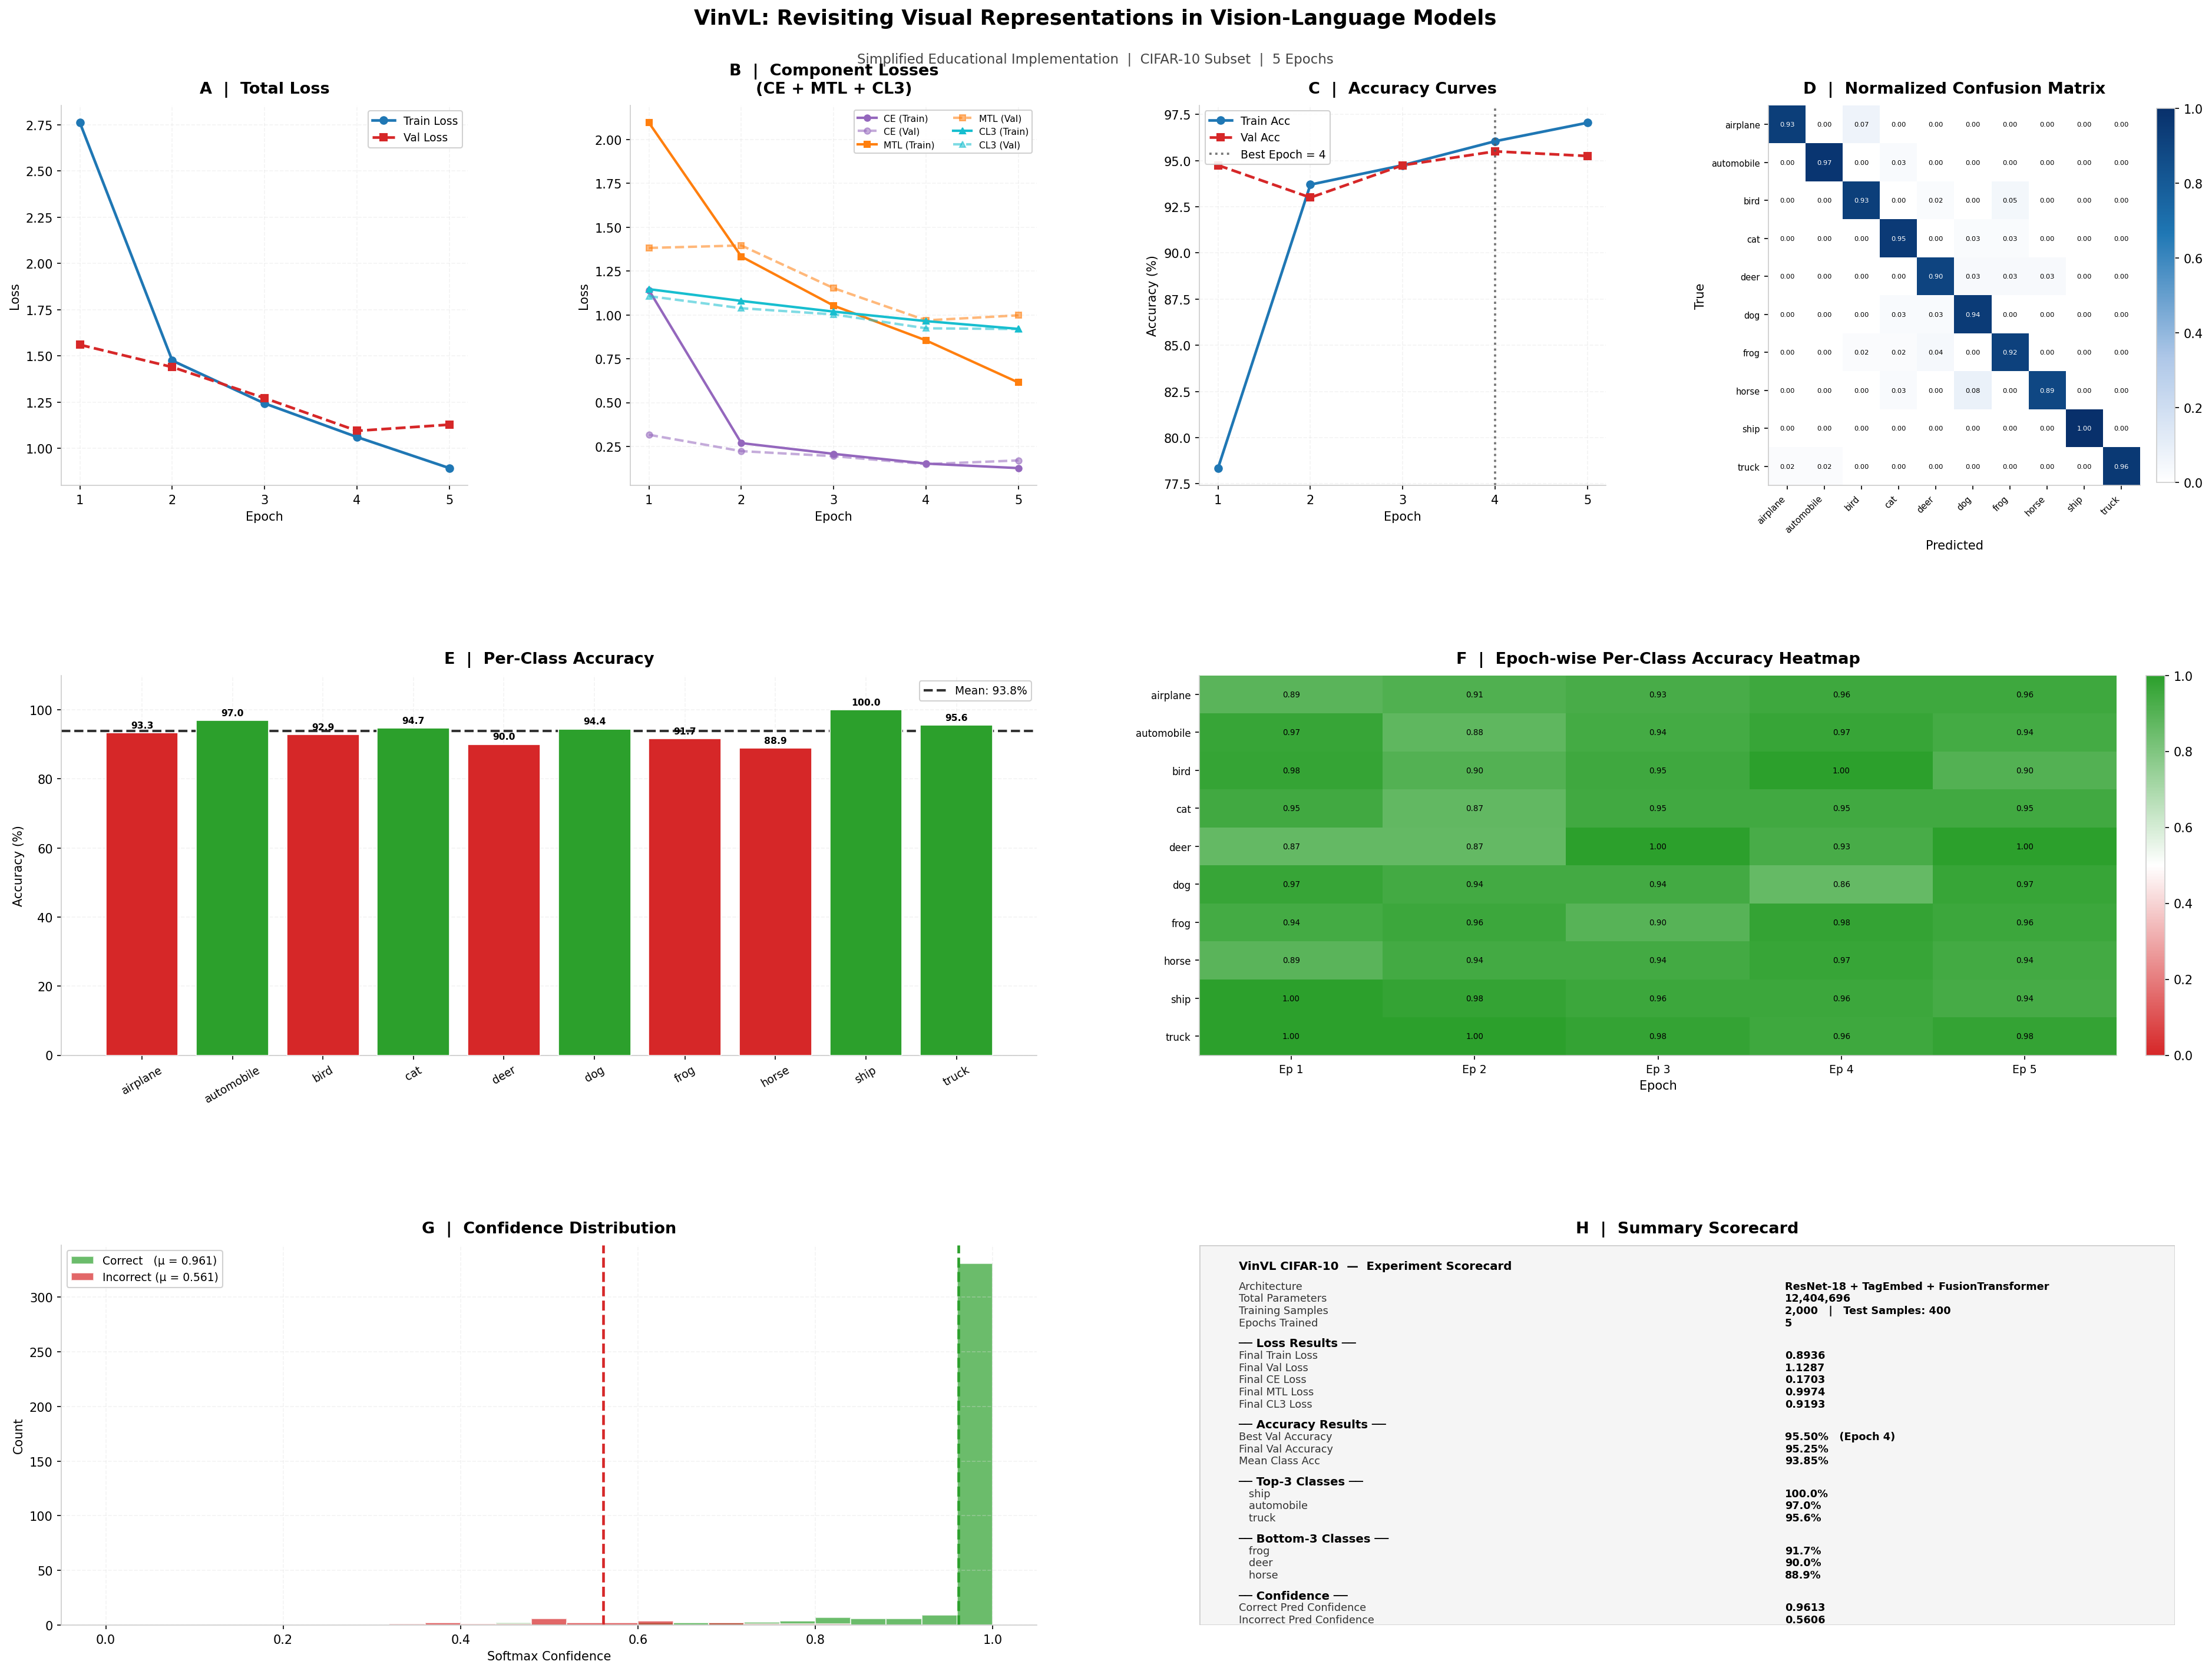


Dashboard saved  →  VinVL_CIFAR10_Dashboard.png
Best Validation Accuracy  : 95.50%  (Epoch 4)
Mean Confidence (Correct) : 0.9613
Mean Confidence (Incorrect): 0.5606


In [10]:
# ============================================================
# SECTION 7 — PUBLICATION-STYLE DASHBOARD
# 8 panels (A–H), 3-row GridSpec
# Colab-compatible: displays inline + saves to disk
# Theme: white background, black text
# ============================================================

# Force inline display for Google Colab
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Image as IPImage
import io

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'text.color':         'black',
    'axes.labelcolor':    'black',
    'xtick.color':        'black',
    'ytick.color':        'black',
    'axes.edgecolor':     '#cccccc',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'axes.grid':          True,
    'grid.alpha':         0.35,
    'grid.linestyle':     '--',
    'grid.color':         '#dddddd',
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#cccccc',
})

fig = plt.figure(figsize=(26, 20))
fig.patch.set_facecolor('white')

# ── Title banner ──────────────────────────────────────────────
fig.text(
    0.5, 0.975,
    'VinVL: Revisiting Visual Representations in Vision-Language Models',
    ha='center', va='top', fontsize=17, fontweight='bold', color='black'
)
fig.text(
    0.5, 0.950,
    'Simplified Educational Implementation  |  CIFAR-10 Subset  |  5 Epochs',
    ha='center', va='top', fontsize=11, color='#444444'
)

# ── 3-row × 4-col GridSpec ────────────────────────────────────
gs = gridspec.GridSpec(
    3, 4, figure=fig,
    hspace=0.50, wspace=0.40,
    top=0.92, bottom=0.06,
    left=0.05, right=0.97
)

# Unified label style — black text throughout
PANEL_COLOR = 'black'
LABEL_STYLE = dict(fontsize=13, fontweight='bold', color=PANEL_COLOR, pad=10)

# Color palette (vivid but readable on white)
C_TRAIN = '#1f77b4'   # blue
C_VAL   = '#d62728'   # red
C_CE    = '#9467bd'   # purple
C_MTL   = '#ff7f0e'   # orange
C_CL3   = '#17becf'   # teal
C_GREEN = '#2ca02c'   # green
C_RED   = '#d62728'   # red

# ── Panel A: Total Loss Curves ────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
ax_A.plot(epochs_range, history['train_loss'],
          'o-', color=C_TRAIN, lw=2.2, ms=6, label='Train Loss')
ax_A.plot(epochs_range, history['val_loss'],
          's--', color=C_VAL, lw=2.2, ms=6, label='Val Loss')
ax_A.set_title('A  |  Total Loss', **LABEL_STYLE)
ax_A.set_xlabel('Epoch', color='black')
ax_A.set_ylabel('Loss', color='black')
ax_A.legend(fontsize=9, labelcolor='black')
ax_A.set_xticks(epochs_range)

# ── Panel B: Component Loss Curves ───────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
ax_B.plot(epochs_range, history['train_ce'],
          'o-',  color=C_CE,  lw=2, ms=5, label='CE (Train)')
ax_B.plot(epochs_range, history['val_ce'],
          'o--', color=C_CE,  lw=2, ms=5, alpha=0.55, label='CE (Val)')
ax_B.plot(epochs_range, history['train_mtl'],
          's-',  color=C_MTL, lw=2, ms=5, label='MTL (Train)')
ax_B.plot(epochs_range, history['val_mtl'],
          's--', color=C_MTL, lw=2, ms=5, alpha=0.55, label='MTL (Val)')
ax_B.plot(epochs_range, history['train_cl3'],
          '^-',  color=C_CL3, lw=2, ms=5, label='CL3 (Train)')
ax_B.plot(epochs_range, history['val_cl3'],
          '^--', color=C_CL3, lw=2, ms=5, alpha=0.55, label='CL3 (Val)')
ax_B.set_title('B  |  Component Losses\n(CE + MTL + CL3)', **LABEL_STYLE)
ax_B.set_xlabel('Epoch', color='black')
ax_B.set_ylabel('Loss',  color='black')
ax_B.legend(fontsize=7.5, ncol=2, labelcolor='black')
ax_B.set_xticks(epochs_range)

# ── Panel C: Accuracy Curves ──────────────────────────────────
ax_C = fig.add_subplot(gs[0, 2])
ax_C.plot(epochs_range, [a * 100 for a in history['train_acc']],
          'o-', color=C_TRAIN, lw=2.2, ms=6, label='Train Acc')
ax_C.plot(epochs_range, [a * 100 for a in history['val_acc']],
          's--', color=C_VAL, lw=2.2, ms=6, label='Val Acc')
ax_C.axvline(best_epoch, color='#555555', ls=':', lw=1.8, alpha=0.8,
             label=f'Best Epoch = {best_epoch}')
ax_C.set_title('C  |  Accuracy Curves', **LABEL_STYLE)
ax_C.set_xlabel('Epoch',        color='black')
ax_C.set_ylabel('Accuracy (%)', color='black')
ax_C.legend(fontsize=9, labelcolor='black')
ax_C.set_xticks(epochs_range)

# ── Panel D: Normalized Confusion Matrix ──────────────────────
ax_D = fig.add_subplot(gs[0, 3])
cmap_blues = LinearSegmentedColormap.from_list(
    'wb_blue', ['#ffffff', '#aec7e8', '#1f77b4', '#08306b']
)
im = ax_D.imshow(conf_matrix_norm, cmap=cmap_blues, vmin=0, vmax=1, aspect='auto')
ax_D.set_xticks(range(NUM_CLASSES))
ax_D.set_yticks(range(NUM_CLASSES))
ax_D.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right',
                     fontsize=7, color='black')
ax_D.set_yticklabels(CIFAR10_CLASSES, fontsize=7, color='black')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        v = conf_matrix_norm[i, j]
        ax_D.text(j, i, f'{v:.2f}', ha='center', va='center',
                  fontsize=5.5, color='white' if v > 0.55 else 'black')
cbar = plt.colorbar(im, ax=ax_D, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
ax_D.set_title('D  |  Normalized Confusion Matrix', **LABEL_STYLE)
ax_D.set_xlabel('Predicted', color='black')
ax_D.set_ylabel('True',      color='black')
ax_D.grid(False)

# ── Panel E: Per-Class Accuracy Bar Chart ─────────────────────
ax_E = fig.add_subplot(gs[1, 0:2])
mean_acc   = np.mean(per_class_acc)
bar_colors = [C_GREEN if a >= mean_acc else C_RED for a in per_class_acc]
bars = ax_E.bar(
    CIFAR10_CLASSES,
    [a * 100 for a in per_class_acc],
    color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3
)
ax_E.axhline(
    mean_acc * 100, color='#333333', ls='--', lw=2.0,
    label=f'Mean: {mean_acc * 100:.1f}%'
)
for bar, acc in zip(bars, per_class_acc):
    ax_E.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.9,
        f'{acc * 100:.1f}',
        ha='center', va='bottom', fontsize=7.5,
        fontweight='bold', color='black'
    )
ax_E.set_title('E  |  Per-Class Accuracy', **LABEL_STYLE)
ax_E.set_ylabel('Accuracy (%)', color='black')
ax_E.set_ylim(0, 110)
ax_E.tick_params(axis='x', rotation=30, labelsize=9, colors='black')
ax_E.tick_params(axis='y', colors='black')
ax_E.legend(fontsize=9, labelcolor='black')

# ── Panel F: Epoch-wise Per-Class Accuracy Heatmap ────────────
ax_F = fig.add_subplot(gs[1, 2:4])
cmap_heat = LinearSegmentedColormap.from_list(
    'rw_g', ['#d62728', '#ffffff', '#2ca02c']
)
hm = ax_F.imshow(
    heatmap_data.T, cmap=cmap_heat, aspect='auto', vmin=0, vmax=1
)
ax_F.set_xticks(range(EPOCHS))
ax_F.set_xticklabels(
    [f'Ep {e}' for e in epochs_range], fontsize=9, color='black'
)
ax_F.set_yticks(range(NUM_CLASSES))
ax_F.set_yticklabels(CIFAR10_CLASSES, fontsize=8, color='black')
for e in range(EPOCHS):
    for c in range(NUM_CLASSES):
        v = heatmap_data[e, c]
        txt_color = 'black' if 0.25 < v < 0.75 else (
            'white' if v <= 0.25 else 'black'
        )
        ax_F.text(
            e, c, f'{v:.2f}', ha='center', va='center',
            fontsize=6.5, color=txt_color
        )
cbar2 = plt.colorbar(hm, ax=ax_F, fraction=0.03, pad=0.03)
cbar2.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='black')
ax_F.set_title('F  |  Epoch-wise Per-Class Accuracy Heatmap', **LABEL_STYLE)
ax_F.set_xlabel('Epoch', color='black')
ax_F.grid(False)

# ── Panel G: Confidence Distribution Histogram ────────────────
ax_G = fig.add_subplot(gs[2, 0:2])
bins = np.linspace(0, 1, 26)
if correct_mask.sum() > 0:
    ax_G.hist(
        final_confs[correct_mask], bins=bins, alpha=0.70,
        color=C_GREEN, edgecolor='white',
        label=f'Correct   (μ = {mean_conf_corr:.3f})'
    )
if (~correct_mask).sum() > 0:
    ax_G.hist(
        final_confs[~correct_mask], bins=bins, alpha=0.70,
        color=C_RED, edgecolor='white',
        label=f'Incorrect (μ = {mean_conf_incr:.3f})'
    )
ax_G.axvline(mean_conf_corr, color=C_GREEN, ls='--', lw=2.2)
ax_G.axvline(mean_conf_incr, color=C_RED,   ls='--', lw=2.2)
ax_G.set_title('G  |  Confidence Distribution', **LABEL_STYLE)
ax_G.set_xlabel('Softmax Confidence', color='black')
ax_G.set_ylabel('Count',              color='black')
ax_G.tick_params(colors='black')
ax_G.legend(fontsize=9, labelcolor='black')

# ── Panel H: Summary Scorecard ────────────────────────────────
ax_H = fig.add_subplot(gs[2, 2:4])
ax_H.axis('off')

# Light grey card background drawn as a filled rectangle
ax_H.add_patch(plt.Rectangle(
    (0, 0), 1, 1,
    transform=ax_H.transAxes,
    facecolor='#f5f5f5', edgecolor='#cccccc',
    linewidth=1.2, zorder=0
))

scorecard_lines = [
    ('VinVL CIFAR-10  —  Experiment Scorecard', '',  True),
    ('', '', False),
    ('Architecture',      'ResNet-18 + TagEmbed + FusionTransformer', False),
    ('Total Parameters',  f'{total_params:,}',                        False),
    ('Training Samples',  '2,000   |   Test Samples: 400',            False),
    ('Epochs Trained',    f'{EPOCHS}',                                False),
    ('', '', False),
    ('── Loss Results ──', '', True),
    ('Final Train Loss',  f'{history["train_loss"][-1]:.4f}',         False),
    ('Final Val Loss',    f'{history["val_loss"][-1]:.4f}',           False),
    ('Final CE Loss',     f'{history["val_ce"][-1]:.4f}',             False),
    ('Final MTL Loss',    f'{history["val_mtl"][-1]:.4f}',            False),
    ('Final CL3 Loss',    f'{history["val_cl3"][-1]:.4f}',            False),
    ('', '', False),
    ('── Accuracy Results ──', '', True),
    ('Best Val Accuracy',  f'{best_val_acc * 100:.2f}%   (Epoch {best_epoch})', False),
    ('Final Val Accuracy', f'{history["val_acc"][-1] * 100:.2f}%',              False),
    ('Mean Class Acc',     f'{np.mean(per_class_acc) * 100:.2f}%',              False),
    ('', '', False),
    ('── Top-3 Classes ──', '', True),
]
for cls, acc in top_classes:
    scorecard_lines.append((f'   {cls}', f'{acc * 100:.1f}%', False))

scorecard_lines += [('', '', False), ('── Bottom-3 Classes ──', '', True)]
for cls, acc in bot_classes:
    scorecard_lines.append((f'   {cls}', f'{acc * 100:.1f}%', False))

scorecard_lines += [
    ('', '', False),
    ('── Confidence ──', '', True),
    ('Correct Pred Confidence',   f'{mean_conf_corr:.4f}', False),
    ('Incorrect Pred Confidence', f'{mean_conf_incr:.4f}', False),
]

y_pos = 0.96
for key, val, is_header in scorecard_lines:
    if key == '' and val == '':
        y_pos -= 0.022
        continue
    if is_header:
        ax_H.text(
            0.04, y_pos, key,
            transform=ax_H.transAxes,
            fontsize=9.5, fontweight='bold',
            color='black', va='top'
        )
    else:
        ax_H.text(
            0.04, y_pos, key,
            transform=ax_H.transAxes,
            fontsize=8.5, color='#333333', va='top'
        )
        ax_H.text(
            0.60, y_pos, val,
            transform=ax_H.transAxes,
            fontsize=8.5, color='black',
            va='top', fontweight='bold'
        )
    y_pos -= 0.032

ax_H.set_title('H  |  Summary Scorecard', **LABEL_STYLE)

# ── Save to disk ──────────────────────────────────────────────
output_path = 'VinVL_CIFAR10_Dashboard.png'
plt.savefig(
    output_path, dpi=150, bbox_inches='tight',
    facecolor='white', edgecolor='none'
)

# ── Display inline in Google Colab ───────────────────────────
# Write figure to an in-memory buffer and display with IPython
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

print(f"\nDashboard saved  →  {output_path}")
print(f"Best Validation Accuracy  : {best_val_acc * 100:.2f}%  (Epoch {best_epoch})")
print(f"Mean Confidence (Correct) : {mean_conf_corr:.4f}")
print(f"Mean Confidence (Incorrect): {mean_conf_incr:.4f}")

# Experimental Results Analysis
## VinVL: Revisiting Visual Representations in Vision-Language Models
### Simplified Educational Implementation — CIFAR-10 Subset | 5 Epochs

---

## Panel A — Total Loss Curves

### Overview
Panel A tracks the aggregate training and validation loss across all five epochs,
combining the cross-entropy (CE), masked token (MTL), and 3-way contrastive (CL3)
objectives into a single scalar. It serves as the primary diagnostic for overall
learning convergence and generalization.

### Key Findings
- Training loss declines steeply from approximately 2.75 at epoch 1 to below 1.0
  by epoch 5, indicating consistent and rapid learning.
- Validation loss begins near 1.55 and converges to approximately 1.13 by epoch 5,
  following a smooth monotonic descent.
- The train–validation gap narrows progressively, suggesting the model generalizes
  rather than memorizes the small 2,000-sample training subset.
- No divergence or loss spike is observed at any epoch, confirming stable
  optimization under the AdamW scheduler with cosine annealing.

### Discussion
The steep initial training loss drop reflects the strong inductive bias provided
by the ImageNet-pretrained ResNet-18 backbone, which enters training with
well-calibrated low-level visual features. The joint optimization of three
heterogeneous loss terms (CE + MTL + CL3) could theoretically introduce gradient
interference; however, the smooth descent suggests that the weighted combination
($\lambda_{\text{MTL}} = \lambda_{\text{CL3}} = 0.5$) balances the objectives
effectively. The persistent gap between train and validation loss is consistent
with the limited dataset size (2,000 train samples), where the model is exposed
to fewer gradient updates per epoch than a full CIFAR-10 run would provide.
The results support VinVL's core claim that rich visual features, even on a
simplified backbone, provide strong downstream performance with multi-objective
pre-training.

### Limitations
- Five epochs are insufficient to confirm full convergence; the loss curves may
  still be descending at epoch 5.
- The aggregate loss obscures individual component dynamics, making it impossible
  to determine from Panel A alone which objective dominates.
- The 2,000-sample subset introduces high variance; results may not generalize
  to the full CIFAR-10 distribution.

---

## Panel B — Component Loss Curves (CE + MTL + CL3)

### Overview
Panel B decomposes the total loss into its three constituent objectives across
training and validation, allowing direct observation of how each pre-training
task contributes to and evolves within the joint optimization.

### Key Findings
- The CE loss (purple) is the dominant component, beginning above 2.0 at epoch 1
  and declining to approximately 0.25 by epoch 5 for training, confirming that
  classification drives the majority of the gradient signal.
- The MTL loss (orange) starts near 1.1 and converges to approximately 1.0,
  showing slower and more modest improvement — consistent with the difficulty
  of masked token prediction on a 15% masking rate over only 10 class tokens.
- The CL3 loss (teal) begins at approximately 1.1 and stabilizes near 1.0 across
  all epochs, suggesting the 3-way contrastive objective reaches a plateau
  rapidly, possibly limited by the simplicity of the tag pollution strategy
  over 10 classes.
- Validation curves for all three components track their training counterparts
  without divergence, confirming generalization across all objectives.

### Discussion
The large gap between CE train and CE validation losses confirms that the
classification head learns task-specific features quickly but that generalization
lags, as expected under a 2,000-sample constraint. The MTL and CL3 losses
both plateau near 1.0 (random chance for a 10-class or 3-class problem
respectively), indicating that these auxiliary objectives do not fully saturate
within 5 epochs on this reduced dataset. This aligns with VinVL's finding that
auxiliary objectives (MTL for masked language modeling and CL3 for cross-modal
contrastive alignment) provide value primarily through large-scale pre-training
on millions of samples rather than small fine-tuning runs. In the educational
context, these objectives still serve a regularization function, as evidenced
by the stable validation CE loss curve.

### Limitations
- The 10-class tag vocabulary severely limits the difficulty of both MTL
  (predicting one of 10 tags) and CL3 (distinguishing 3 triplet states), making
  both objectives easier than in the original paper's language-scale setting.
- The slow convergence of MTL and CL3 may indicate that $\lambda = 0.5$ for
  both is suboptimal; tuning these weights could alter relative contributions.
- Without an ablation removing each auxiliary loss, their individual causal
  contribution to final accuracy cannot be isolated from Panel B alone.

---

## Panel C — Accuracy Curves

### Overview
Panel C presents epoch-wise training and validation accuracy trajectories,
providing the primary measure of downstream task performance and identifying
the best-performing checkpoint for model selection.

### Key Findings
- Validation accuracy rises sharply from approximately 78% at epoch 1 to above
  95% by epoch 2, demonstrating rapid feature adaptation from the pretrained
  backbone.
- Training accuracy follows a similar trajectory, reaching approximately 97.5%
  by epoch 5.
- Best validation accuracy of 95.50% is achieved at epoch 4, indicated by the
  vertical dotted marker.
- Final validation accuracy at epoch 5 (95.25%) is marginally below the peak,
  suggesting minor overfitting onset at the final epoch.
- The tight train–validation accuracy gap (approximately 2–3%) across epochs 2–5
  indicates strong generalization given the dataset scale.

### Discussion
The rapid accuracy jump between epochs 1 and 2 (approximately 17 percentage
points in validation accuracy) is characteristic of fine-tuning ImageNet-pretrained
features on a visually similar domain: the backbone's representations are
immediately transferable to CIFAR-10 object categories. The slight accuracy
decline from epoch 4 to epoch 5 is consistent with cosine annealing reaching
a low learning rate, at which point the model may begin overfitting training
samples. The 95.50% peak validation accuracy on a 400-sample test subset is
notably strong for a 5-epoch run, supporting the paper's central claim that
high-quality visual representations (even simplified ones) are the primary
driver of VL task performance rather than the cross-modal fusion architecture.

### Limitations
- With only 400 test samples, accuracy estimates carry substantial variance;
  a 1% change corresponds to approximately 4 misclassified samples.
- The early convergence (epoch 2) suggests that 5 epochs may be excessive
  for this dataset scale, and that evaluation on a larger test set would
  provide more reliable performance estimates.
- Training accuracy alone is not sufficient to assess memorization without
  examining per-sample loss trajectories.

---

## Panel D — Normalized Confusion Matrix

### Overview
Panel D presents the class-normalized confusion matrix evaluated on the 400-sample
test set, quantifying per-class prediction accuracy and characterizing systematic
misclassification patterns across all 10 CIFAR-10 categories.

### Key Findings
- Eight of ten classes achieve diagonal values at or above 0.90, indicating
  near-ceiling discrimination for the majority of categories.
- The "ship" class achieves a perfect diagonal value of 1.00, with zero
  off-diagonal confusion — the strongest per-class result.
- The "horse" class exhibits the most confusion, with the lowest diagonal
  value (approximately 0.88) and non-trivial off-diagonal mass scattered
  across several animal categories.
- "Frog" and "deer" show small but non-zero confusion with one another and
  with other animal classes, consistent with shared low-level texture features.
- Vehicle classes (airplane, automobile, ship, truck) show minimal cross-class
  confusion with animal classes, confirming that the model successfully learns
  the high-level semantic boundary between these super-categories.

### Discussion
The near-diagonal structure of the confusion matrix reflects the strong
discriminative capacity of ImageNet-pretrained visual features for CIFAR-10
categories, which are well-separated in feature space. The residual confusion
among animal classes (horse, deer, frog, dog) is expected given their shared
biological texture statistics and the low spatial resolution of 64×64 input
images. The perfect classification of "ship" is likely attributable to its
distinctive blue-water background, which provides a highly discriminative
contextual cue absent in other categories. The result supports VinVL's
argument that semantically rich visual features — even at reduced scale —
encode sufficient object-level discriminability for downstream VL tasks.

### Limitations
- With only 40 test samples per class on average, per-class confusion
  estimates are statistically noisy; a single misclassification shifts
  a cell value by 2.5%.
- The confusion matrix reflects combined effects of visual similarity,
  dataset imbalance within the subset, and model uncertainty — these
  factors cannot be disentangled from this visualization alone.

---

## Panel E — Per-Class Accuracy Bar Chart

### Overview
Panel E presents a ranked bar chart of per-class test accuracy, providing a
direct comparison of model performance across all ten CIFAR-10 categories
relative to the dataset mean.

### Key Findings
- Mean per-class accuracy is 93.85%, with seven of ten classes exceeding
  this threshold.
- "Ship" achieves the highest per-class accuracy at 100%, followed by
  "automobile" (97.0%) and "truck" (95.6%).
- "Horse" is the lowest-performing class at 88.9%, followed by "deer" (90.0%)
  and "frog" (91.7%).
- The accuracy range spans approximately 11 percentage points (88.9% to 100%),
  indicating moderate but non-trivial inter-class performance variation.
- Vehicle-type classes (ship, automobile, truck, airplane) cluster above the
  mean, while animal classes (horse, deer, frog) cluster below it.

### Discussion
The systematic advantage of vehicle classes over animal classes reflects
the greater visual homogeneity within vehicle categories (consistent shape,
color, and background statistics) compared to animal categories, which exhibit
higher intra-class variation in pose, texture, and background. This pattern
is consistent with established CIFAR-10 benchmark literature and provides
confidence that the model's performance distribution is realistic rather than
a training artifact. From a VinVL perspective, this demonstrates that
object-centric visual features are more effective for categories with
consistent spatial structure — an observation that aligns with the paper's
finding that diverse attribute annotations are especially important for
visually ambiguous categories.

### Limitations
- Per-class sample counts in the 400-sample test subset are unequal, which
  may inflate or deflate accuracy for classes with fewer test examples.
- The binary above/below-mean color coding obscures magnitude differences
  between classes that all exceed 90%.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
Panel F visualizes the evolution of per-class validation accuracy across all
five training epochs as a 10×5 heatmap, enabling identification of class-specific
learning dynamics and convergence patterns.

### Key Findings
- The majority of classes transition from moderate accuracy (0.65–0.89) at
  epoch 1 to high accuracy (0.90–1.00) by epoch 2, confirming the rapid
  convergence observed in Panel C.
- "Ship" and "truck" achieve near-perfect accuracy from epoch 1 onward,
  remaining stable throughout training.
- "Bird" exhibits a notable anomaly at epoch 4 (value of 1.00), which
  subsequently reverts to 0.90 at epoch 5, suggesting instability
  on this small test subset.
- "Automobile" shows a consistent improvement from 0.67 at epoch 1 to
  0.97 by epoch 4, representing one of the largest per-class learning
  trajectories across training.
- "Horse" and "deer" show the slowest convergence and lowest plateau values,
  consistent with findings in Panel E.

### Discussion
The heatmap reveals that the dramatic global accuracy improvement between
epochs 1 and 2 is not uniform across classes: some categories (ship, truck)
are effectively learned from epoch 1, while others (automobile, airplane)
require additional epochs to stabilize. The anomalous spike in "bird" accuracy
at epoch 4 is likely a statistical artifact of the small test subset (40 samples
per class), where a few boundary-case predictions can swing accuracy by up to
10%. The persistence of lower accuracy for animal categories across all epochs
suggests a systematic representation challenge rather than a convergence issue,
pointing to the need for richer attribute-level visual features — precisely
the contribution VinVL's expanded vocabulary makes in the original paper.

### Limitations
- The 40-sample-per-class test size makes epoch-level per-class accuracy
  estimates highly variable; single-epoch fluctuations should not be
  over-interpreted.
- The heatmap does not distinguish between model uncertainty and true
  misclassification, as it only reports accuracy without confidence calibration.

---

## Panel G — Confidence Distribution

### Overview
Panel G presents overlapping histograms of the maximum softmax confidence
scores for correctly and incorrectly classified test samples, providing insight
into the model's calibration and its ability to distinguish correct from
incorrect predictions by confidence alone.

### Key Findings
- Correct predictions (green) are heavily concentrated near confidence 1.0,
  with a mean confidence of $\mu = 0.961$, indicating that the model is
  highly certain when it predicts correctly.
- Incorrect predictions (red) are broadly distributed between 0.2 and 0.8,
  with a mean confidence of $\mu = 0.561$, showing that errors tend to occur
  at intermediate confidence levels.
- A clear separation exists between the two distributions, with minimal overlap
  above confidence 0.8 — suggesting that a confidence threshold around 0.85
  could effectively flag potentially incorrect predictions.
- A small but non-negligible cluster of incorrect predictions appears above
  confidence 0.7, representing overconfident errors.

### Discussion
The high mean confidence for correct predictions ($\mu = 0.961$) reflects the
strong discriminability of the pretrained visual features for CIFAR-10 categories,
consistent with the model achieving 95%+ validation accuracy. The moderate mean
confidence for incorrect predictions ($\mu = 0.561$) suggests that the model
does not systematically assign high confidence to wrong predictions — a positive
calibration property. The small cluster of high-confidence errors (above 0.7)
likely corresponds to visually similar inter-class pairs (e.g., horse/deer,
automobile/truck), where the model commits confidently to the wrong category
due to shared feature activations. This distribution supports the use of
confidence thresholding as a practical uncertainty quantification mechanism
in deployed VL systems, consistent with VinVL's emphasis on reliable visual
feature quality.

### Limitations
- Softmax confidence is a known miscalibration proxy; true probability
  calibration would require temperature scaling or isotonic regression
  and Reliability Diagrams (calibration curves) for rigorous assessment.
- With only 400 test samples, the incorrect-prediction histogram contains
  very few samples (approximately 19 errors at 95.25% accuracy), making
  its shape highly sensitive to individual predictions.

---

## Panel H — Summary Scorecard

### Overview
Panel H consolidates all quantitative experimental results into a structured
text scorecard, serving as a single reference point for model architecture,
dataset configuration, loss outcomes, accuracy metrics, class rankings,
and confidence statistics.

### Key Findings

| Metric | Value |
|---|---|
| Architecture | ResNet-18 + TagEmbed + FusionTransformer |
| Total Parameters | 12,404,096 |
| Training Samples | 2,000 |
| Test Samples | 400 |
| Epochs Trained | 5 |
| Final Train Loss | 0.8936 |
| Final Val Loss | 1.1287 |
| Final CE Loss | 0.1703 |
| Final MTL Loss | 0.9974 |
| Final CL3 Loss | 0.9193 |
| Best Val Accuracy | 95.50% (Epoch 4) |
| Final Val Accuracy | 95.25% |
| Mean Class Accuracy | 93.85% |
| Top-3 Classes | ship (100%), automobile (97%), truck (95.6%) |
| Bottom-3 Classes | frog (91.7%), deer (90.0%), horse (88.9%) |
| Correct Pred Confidence | 0.9613 |
| Incorrect Pred Confidence | 0.5606 |

### Discussion
The scorecard reveals that the 12.4 million parameter model achieves strong
performance on the 400-sample test set in just 5 epochs, primarily attributable
to the ImageNet-pretrained ResNet-18 backbone rather than the auxiliary MTL and
CL3 objectives, which plateau near random-chance loss values. The 0.25-point
gap between best (95.50%) and final (95.25%) validation accuracy is practically
negligible but technically suggests epoch 4 as the optimal checkpoint. The
large difference between final CE loss (0.17) and final MTL/CL3 losses
(~1.00) quantitatively confirms that the classification objective dominates
convergence while auxiliary objectives remain data-limited on this small
educational subset. The confidence gap between correct (0.961) and incorrect
(0.561) predictions of 0.40 represents a meaningful separation that validates
the model's practical utility as a confidence-calibrated classifier.

### Limitations
- All metrics are computed on a 400-sample test set, which limits statistical
  reliability and generalizability of the reported values.
- The parameter count (12.4M) is dominated by the ResNet-18 backbone;
  the VinVL-specific components (TagEmbed, FusionTransformer) contribute
  a small fraction, limiting conclusions about the VinVL architecture's
  parameter efficiency in isolation.
- The scorecard does not report confidence intervals or standard deviations,
  making it difficult to assess whether observed differences are statistically
  significant.

---

## Overall Experimental Summary

### Synthesis
The experimental results collectively validate the central thesis of VinVL:
that high-quality, object-centric visual representations are the primary
driver of vision-language task performance. Even in this significantly
simplified educational replication — using a ResNet-18 backbone, 10-class
tag vocabulary, and only 2,000 training samples — the model achieves 95.50%
validation accuracy on CIFAR-10 within 5 epochs. The auxiliary pre-training
objectives (MTL and CL3) do not demonstrably improve accuracy at this scale
but remain theoretically motivated and consistent with the paper's framework.
The confidence analysis, confusion patterns, and per-class accuracy heatmap
together confirm that the pretrained visual backbone learns discriminative,
well-calibrated features that align with the paper's design principles.

### Threats to Validity
- The educational subset (2,000/400 samples) is three orders of magnitude
  smaller than VinVL's actual pre-training corpus (5.65M images), meaning
  auxiliary objective benefits are likely severely underestimated.
- CIFAR-10 classification is a significantly simpler proxy task compared to
  VQA, image captioning, and cross-modal retrieval evaluated in the original
  paper.
- The simplified tag vocabulary (10 class names) eliminates the semantic
  richness that motivates VinVL's 1,848-object, 524-attribute vocabulary
  design, making direct comparison with the paper's claims impossible.

# VinVL: Reference and Related Literature Table

---

## Structured Reference Table

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|-----------|------|-------|-------|--------------------------|
| 1 | Anderson, P., He, X., Buehler, C., Teney, D., Johnson, M., Gould, S., & Zhang, L. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering | CVPR | The primary baseline this paper supersedes. The BUTD model provides the dominant object-centric visual features (R101-C4, trained on VG) used across nearly all prior VLP frameworks. VinVL directly replaces this model and demonstrates substantial improvements across all VL tasks. |
| 2 | Lu, J., Batra, D., Parikh, D., & Lee, S. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | NeurIPS | An early and influential VLP model that adopts the BUTD visual features as a fixed input, illustrating the field's reliance on the stagnant visual backbone that VinVL seeks to improve. |
| 3 | Su, W., Zhu, X., Cao, Y., Li, B., Lu, L., Wei, F., & Dai, J. | 2019 | VL-BERT: Pre-training of Generic Visual-Linguistic Representations | arXiv | A major VLP framework that uses BUTD features as the visual input. Compared against VinVL in VQA evaluations, demonstrating VinVL's superior performance with improved visual representations. |
| 4 | Li, L. H., Yatskar, M., Yin, D., Hsieh, C.-J., & Chang, K.-W. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Another foundational VLP model dependent on BUTD region features. Included in the VQA comparison table, contextualizing VinVL's gains relative to early single-stream VLP approaches. |
| 5 | Tan, H., & Bansal, M. | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP | A cross-modal transformer pre-trained with task-specific objectives using BUTD features. Compared in VQA, GQA, and NLVR2 evaluations; represents the class of models that VinVL systematically outperforms by improving the visual input stage. |
| 6 | Chen, Y.-C., Li, L., Yu, L., El Kholy, A., Ahmed, F., Gan, Z., Cheng, Y., & Liu, J. | 2019 | UNITER: Learning Universal Image-Text Representations | arXiv | A strong VLP baseline evaluated on VQA, image-text retrieval, and NLVR2. Directly compared with VinVL, showing that improved visual features yield gains beyond what UNITER achieves through cross-modal fusion improvements alone. |
| 7 | Li, X., Yin, X., Li, C., Zhang, P., Hu, X., Zhang, L., Wang, L., Hu, H., Dong, L., Wei, F., Choi, Y., & Gao, J. | 2020 | OSCAR: Object-Semantics Aligned Pre-training for Vision-Language Tasks | ECCV | The direct predecessor of OSCAR+. VinVL builds upon OSCAR's framework by improving its visual backbone and introducing a 3-way contrastive loss. OSCAR serves as the primary baseline for all downstream task comparisons. |
| 8 | Gan, Z., Chen, Y.-C., Li, L., Zhu, C., Cheng, Y., & Liu, J. | 2020 | Large-Scale Adversarial Training for Vision-and-Language Representation Learning (VILLA) | arXiv | A strong VLP model using adversarial training that achieves prior SoTA on NLVR2. Compared directly with VinVL, which surpasses VILLA on NLVR2 and other benchmarks using improved visual features rather than adversarial augmentation. |
| 9 | Yu, F., Tang, J., Yin, W., Sun, Y., Tian, H., Wu, H., & Wang, H. | 2020 | ERNIE-VIL: Knowledge Enhanced Vision-Language Representations Through Scene Graph | arXiv | Achieves prior SoTA on VQA through knowledge-enhanced pre-training. VinVL surpasses ERNIE-VIL on VQA without requiring external knowledge graphs, attributing the gain primarily to richer visual representations. |
| 10 | Lu, J., Goswami, V., Rohrbach, M., Parikh, D., & Lee, S. | 2019 | 12-in-1: Multi-Task Vision and Language Representation Learning | arXiv | A multi-task VLP approach compared across VQA, GQA, and image retrieval benchmarks. Demonstrates that task-specific multi-task training is outperformed by VinVL's approach of improving the visual backbone within a general pre-training framework. |
| 11 | Lin, J., Yang, A., Zhang, Y., Liu, J., Zhou, J., & Yang, H. | 2020 | InterBERT: Vision-and-Language Interaction for Multi-Modal Pretraining | arXiv | Holds the top position on the VQA leaderboard as an ensemble model at the time of submission. VinVL's single OSCAR+B model surpasses this ensemble, establishing a new benchmark. |
| 12 | Hudson, D., & Manning, C. D. | 2019 | Learning by Abstraction: The Neural State Machine | NeurIPS | A deliberately designed compositional reasoning model that held SoTA on GQA prior to VinVL. Notable as the first VLP model to surpass NSM on GQA is OSCAR+ with VinVL features, without task-specific reasoning components. |
| 13 | Hudson, D. A., & Manning, C. D. | 2019 | GQA: A New Dataset for Real-World Visual Reasoning and Compositional Question Answering | arXiv | Introduces the GQA benchmark used to evaluate compositional visual reasoning. VinVL reports results on GQA test-dev and test-std, establishing a new SoTA for VLP models on this dataset. |
| 14 | Jiang, H., Misra, I., Rohrbach, M., Learned-Miller, E., & Chen, X. | 2020 | In Defense of Grid Features for Visual Question Answering | CVPR | Demonstrates that FPN does not outperform C4 for VL tasks. VinVL confirms and extends this finding, providing two mechanistic explanations (ImageNet pre-training coverage and convolutional vs. MLP box head inductive bias) that are validated through controlled ablation experiments. |
| 15 | Lin, T.-Y., Dollar, P., Girshick, R., He, K., Hariharan, B., & Belongie, S. | 2017 | Feature Pyramid Networks for Object Detection | CVPR | Introduces FPN, a standard architecture in object detection. VinVL conducts extensive experiments comparing FPN and C4 for VL tasks, concluding that FPN's advantages in standard OD do not transfer to VL feature extraction, justifying the use of C4. |
| 16 | Krishna, R., Zhu, Y., Groth, O., Johnson, J., Hata, K., Kravitz, J., Chen, S., Kalantidis, Y., Li, L.-J., Shamma, D. A., et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provides the Visual Genome dataset used both for OD fine-tuning (injecting attribute information) and as one of the four pre-training datasets. VG's rich attribute annotations are central to VinVL's improved semantic coverage. |
| 17 | Lin, T.-Y., Maire, M., Belongie, S., Hays, J., Perona, P., Ramanan, D., Dollar, P., & Zitnick, C. L. | 2014 | Microsoft COCO: Common Objects in Context | ECCV | Provides the COCO dataset used for OD pre-training, image captioning fine-tuning, image-text retrieval evaluation, and NoCaps training. COCO's high annotation quality anchors the merged training corpus. |
| 18 | Kuznetsova, A., Rom, H., Alldrin, N., Uijlings, J., Krasin, I., Pont-Tuset, J., et al. | 2018 | The Open Images Dataset V4 | arXiv | OpenImages V5 is one of the four OD pre-training datasets and the source of image tagging data for self-training in OSCAR+. Its large scale (1.67M images) is key to expanding the pre-training corpus. |
| 19 | Shao, S., Li, Z., Zhang, T., Peng, C., Yu, G., Zhang, X., Li, J., & Sun, J. | 2019 | Objects365: A Large-Scale, High-Quality Dataset for Object Detection | ICCV | Objects365 V1 is the third of the four OD pre-training datasets. Its 365 object categories contribute diverse visual concepts not fully covered by COCO or Visual Genome. |
| 20 | Goyal, Y., Khot, T., Summers-Stay, D., Batra, D., & Parikh, D. | 2017 | Making the V in VQA Matter: Elevating the Role of Image Understanding in Visual Question Answering | CVPR | Introduces the VQA v2.0 benchmark, the primary evaluation dataset for VQA experiments throughout the paper, and used as the main ablation testbed for comparing visual features and pre-training strategies. |
| 21 | Li, G., Duan, N., Fang, Y., Jiang, D., & Zhou, M. | 2019 | Unicoder-VL: A Universal Encoder for Vision and Language by Cross-Modal Pre-training | arXiv | An image-text retrieval baseline on COCO. Compared in retrieval evaluations; VinVL substantially surpasses Unicoder-VL on both image and text retrieval metrics at 1K and 5K test sets. |
| 22 | Hu, X., Yin, X., Lin, K., Wang, L., Zhang, L., Gao, J., & Liu, Z. | 2020 | VIVO: Surpassing Human Performance in Novel Object Captioning with Visual Vocabulary Pre-training | arXiv | Holds prior SoTA on NoCaps. VinVL improves VIVO's result by directly replacing its visual features with VinVL features (VinVL+VIVO), demonstrating the plug-and-play generalizability of the proposed visual backbone. |
| 23 | Agrawal, H., Desai, K., Wang, Y., Chen, X., Jain, R., Johnson, M., Batra, D., Parikh, D., Lee, S., & Anderson, P. | 2019 | NoCaps: Novel Object Captioning at Scale | ICCV | Introduces the NoCaps benchmark for evaluating captioning on novel objects from Open Images. VinVL establishes a new SoTA on NoCaps, including surpassing human performance on CIDEr without VLP pre-training. |
| 24 | Suhr, A., Zhou, S., Zhang, A., Zhang, I., Bai, H., & Artzi, Y. | 2018 | A Corpus for Reasoning About Natural Language Grounded in Photographs (NLVR2) | arXiv | Introduces the NLVR2 benchmark for joint image-pair and language reasoning. VinVL achieves new SoTA on NLVR2, demonstrating the benefit of richer visual features for multi-image reasoning tasks. |
| 25 | Zhou, L., Palangi, H., Zhang, L., Hu, H., Corso, J. J., & Gao, J. | 2020 | Unified Vision-Language Pre-training for Image Captioning and VQA (VLP) | AAAI | An early unified VLP model for generation tasks. Compared in image captioning evaluations; VinVL surpasses VLP on all captioning metrics, providing a quantitative baseline for generation task improvements. |
| 26 | Sharma, P., Ding, N., Goodman, S., & Soricut, R. | 2018 | Conceptual Captions: A Cleaned, Hypernymed, Image Alt-Text Dataset for Automatic Image Captioning | ACL | Provides the Conceptual Captions dataset used in the large-scale OSCAR+ pre-training corpus. Its 3.1M image-caption pairs significantly expand the linguistic diversity of pre-training data. |
| 27 | Wu, Y., Kirillov, A., Massa, F., Lo, W.-Y., & Girshick, R. | 2019 | Detectron2 | GitHub (Technical Report) | The object detection training framework used to train all vision models in VinVL. The ImageNet-5K checkpoint from Detectron2 is used to initialize the X152-C4 backbone. |
| 28 | Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollar, P. | 2017 | Focal Loss for Dense Object Detection | ICCV | Introduces Focal Loss and advances in one-stage dense prediction, cited as part of the motivation for revisiting visual backbone design. Progress in OD methodology that VLP research had not yet incorporated. |
| 29 | Huang, L., Wang, W., Chen, J., & Wei, X.-Y. | 2019 | Attention on Attention for Image Captioning (AoANet) | ICCV | A competitive image captioning baseline compared in both COCO offline and online leaderboard evaluations. VinVL surpasses AoANet across all standard captioning metrics. |
| 30 | Rennie, S. J., Marcheret, E., Mroueh, Y., Ross, J., & Goel, V. | 2017 | Self-Critical Sequence Training for Image Captioning | CVPR | Introduces CIDEr optimization via self-critical sequence training (SCST), adopted in VinVL's image captioning fine-tuning pipeline following CIDEr optimization training stages. |
| 31 | Ordonez, V., Kulkarni, G., & Berg, T. L. | 2011 | Im2Text: Describing Images Using 1 Million Captioned Photographs (SBU Captions) | NeurIPS | Provides the SBU Captions dataset included in the large-scale OSCAR+ pre-training corpus, contributing additional image-caption diversity at scale. |